# PyMOL-Copilot: a local model that writes safe PyMOL commands

**Authors:** Martin Urban and Hannah Kullik · **Deliverable of:** the V1
specification (`SPECIFICATION.md`) · **Built by:**
`notebooks/build_notebook.py` from `notebooks/source/pymol_copilot.py`

PyMOL is a molecular viewer driven by a command language. PyMOL-Copilot
lets a structural biologist type what they want, in plain English, and
get back a *plan*: a short list of PyMOL commands. The plan is checked,
rehearsed in a separate PyMOL process, shown to the user, and applied to
their session only when they approve it. A small language model running
on the user's own machine writes the plan; nothing leaves the machine.

This notebook is the project's complete record. It reads on its own:
every stage is explained, the real code of each stage is shown, and
every number is recomputed here from the evidence committed with the
repository. Its sections:

0. How to read and run this notebook
1. The problem and the system
2. Dataset generation
3. The oracle and its conformance evidence
4. The label audit
5. The split and decontamination
6. The untuned baseline
7. Fine-tuning
8. The comparison, per category
9. Using the model: the copilot in PyMOL
10. Limits, versions, licensing and retention

## 0. How to read and run this notebook

The committed notebook was executed once, top to bottom, and saved with
its outputs, so it can be read without running anything. Stages that
take hours (generating the dataset, training on a GPU, evaluating
thousands of samples) show their real code behind a flag that is off,
and the notebook loads what those runs recorded instead. Stages that
take milliseconds run live. The end-user demonstration in section 9
runs the real system against the fine-tuned model.

To run it yourself you need Linux, the environment in
`requirements-notebook.txt` (see `docs/development_setup.md`), and for
section 9 a local Lemonade server serving the fine-tuned model.

In [1]:
# Copyright 2026 PyMOL Copilot contributors.
"""Set up the kernel: the repository's packages, and every flag."""

import importlib
import os
import sys
import warnings
from pathlib import Path

# The tokenizer's progress bars need ipywidgets, which this kernel lacks.
warnings.filterwarnings("ignore", message="IProgress not found")
# The notebook's helpers sit next to it, in notebooks/.
sys.path.insert(0, str(Path.cwd()))
support = importlib.import_module("notebook_support")

support.setup_paths()

#: Heavy stages: their code is shown, but they run only when switched on.
RUN_GENERATION = False
RUN_TRAINING = False
#: The end-user demo needs a Lemonade server with the fine-tuned model.
RUN_DEMO = os.environ.get("PMC_NOTEBOOK_DEMO") == "1"

print(support.host_description())

{'os': 'Ubuntu 24.04.4 LTS', 'kernel': 'Linux 5.15.167.4-microsoft-standard-WSL2', 'architecture': 'x86_64', 'python': '3.12.13'}


## 1. The problem and the system

A PyMOL session holds molecules and how they are drawn. Commands change
that: `color red, chain A` colours every atom of chain A, `show sticks,
resn ZN` draws the zinc ions as sticks. Writing these commands needs
PyMOL's selection syntax; asking a general chat model to write them is
unsafe, because PyMOL's language can also run Python, load files and
call plugins.

PyMOL-Copilot therefore defines a **restricted command language**: five
verbs (`select`, `color`, `show`, `hide`, `orient`) over selections built
from six terms (`chain`, `resi`, `resn`, `name`, `hetatm`, `polymer`)
joined by `and`, `or` and `not`. Everything else is refused before
anything runs. A request goes through these steps:

1. **Snapshot.** The client extracts the live session into a canonical
   description and checks that it can be rebuilt exactly.
2. **Structure card.** The snapshot becomes a text *card* listing the
   object, its atoms and their current colours and representations.
3. **Generation.** The local model receives the card and the intent and
   writes the plan, optionally constrained by a grammar that only admits
   the restricted language.
4. **Validation.** The plan is parsed, checked by an independent policy,
   and rehearsed in a *fresh* PyMOL process. A failure is fed back for at
   most two repairs.
5. **Approval.** The user sees the commands, the atoms each selection
   matched, and what was and was not checked, and types `copilot_apply`.
6. **Apply and recovery.** Before the first command runs, the session is
   saved; if any command fails, it is restored.

The model is the only learned part. This notebook is about how it was
made and how good it is.

## 2. Dataset generation

A model learns to write plans from examples: a structure, an intent and
the correct plan. We cannot collect these from users, and a plan written
by hand or by another model may simply be wrong. So every example is
made **program-first**: the plan is enumerated by code, its result is
predicted by an *oracle* that never touches PyMOL, the plan is executed
in real PyMOL, and the example is kept only if PyMOL's result equals the
prediction exactly.

The structures are 24 small synthetic proteins (`pmc_data.structures`)
covering what a selection can trip over: several chains, hetero atoms
(zinc, water), several coordinate states, alternate locations and
insertion codes. They are synthetic on purpose: no PDB-derived data, and
every atom is known. Here is one of them, and the card the model sees:

In [2]:
from pmc_core.card import render_for_runtime
from pmc_data.structures import StructureSpec
from pmc_data.structures import build_structure
from pmc_data.structures import enumerate_structures

specs = {spec.spec_id: spec for spec in enumerate_structures(20260921)}
gold = support.load_jsonl("src/pmc_data/gold/gold_samples.jsonl")
demo_sample = next(row for row in gold if row["sample_id"] == "gold_056")
demo_spec = StructureSpec.from_dict(demo_sample["structure"]["spec"])
snapshot = build_structure(demo_spec)
card = render_for_runtime(snapshot)
print(f"{len(specs)} structures; '{demo_spec.spec_id}' has", end=" ")
print(f"{sum(len(state.atoms) for state in snapshot.states)} atoms")
print("\n".join(card.splitlines()[:12]))
print("...")

24 structures; 'two_chains_hetatm' has 36 atoms
card-version=1
status=complete
unsupported state=measurement-objects route=plan-report
unsupported state=explicit-polymer-classification route=contract-freeze
object name="pmc_structure" enabled=true states=1
state index=1 atoms=36 emitted=36 truncated=false
atom state=1 serial=3 name="C" alt="" resn="ALA" chain="A" resv=1 ins="" elem="C" hetatm=false occupancy=1 b_factor=20 color=3 reps="lines" label=null coord="-7.5,16,21"
atom state=1 serial=2 name="CA" alt="" resn="ALA" chain="A" resv=1 ins="" elem="C" hetatm=false occupancy=1 b_factor=20 color=3 reps="lines" label=null coord="0.5,-19,-28"
atom state=1 serial=1 name="N" alt="" resn="ALA" chain="A" resv=1 ins="" elem="N" hetatm=false occupancy=1 b_factor=20 color=3 reps="lines" label=null coord="-25.5,-29,-16.5"
atom state=1 serial=4 name="O" alt="" resn="ALA" chain="A" resv=1 ins="" elem="O" hetatm=false occupancy=1 b_factor=20 color=3 reps="lines" label=null coord="-22.5,15,12"
atom 

For each structure, `pmc_data.taxonomy.enumerate_plans` enumerates plans
across every verb, term and expression shape, each with a templated
intent. One of them:

In [3]:
from pmc_data.taxonomy import enumerate_plans

candidates = enumerate_plans(snapshot, seed=20260921)
example = next(c for c in candidates if c.category.startswith("color+select"))
print(f"{len(candidates)} candidate plans for this structure")
print("intent:  ", example.intent)
print("category:", example.category, "|", example.difficulty)
print("plan:")
print(example.plan.render_pml(), end="")

567 candidate plans for this structure
intent:   Select chain A and color it neptunium.
category: color+select/chain/single | intermediate
plan:
select copilot_sel0001, chain A
color neptunium, copilot_sel0001


The corpus run attempts 4,000 of these plans across all structures,
executes each one in a fresh PyMOL process, and keeps those whose result
matches the oracle. This is its real entry point; it takes 10-20 minutes
on a CPU and is switched off here:

In [4]:
if RUN_GENERATION:
    from pmc_data import corpus_cli

    corpus_cli.main(["--config", "configs/generation/corpus.json"])
else:
    print("RUN_GENERATION is off; loading the committed record instead.")

RUN_GENERATION is off; loading the committed record instead.


## 3. The oracle and its conformance evidence

The oracle (`pmc_data.oracle`) predicts, without PyMOL, the state a plan
leaves behind and how many atoms each selection matches. It refuses
rather than guesses: where PyMOL's behaviour cannot be predicted from
the structure alone, it names what it cannot check. Its prediction for
the plan above:

In [5]:
from pmc_data.oracle import apply_plan

outcome = apply_plan(snapshot, example.plan)
print("selections:", outcome.selection_counts)
print("state predicted:", outcome.snapshot is not None)
print("not checked:", outcome.unsupported or "nothing")

selections: (('copilot_sel0001', 18),)
state predicted: True
not checked: nothing


Every corpus attempt is therefore a **differential test** of the oracle
against pinned Open-Source PyMOL: the plan is predicted, then executed,
and the two resulting states are compared byte for byte by fingerprint.
A disagreement, or a PyMOL process that fails, is a *rejection*; a plan
the oracle declines to grade is *unsupported*. The split's own corpus was generated on a Mac (3,388 of
4,000 attempts kept). Its per-category report was not committed, so the
corpus was regenerated on this Linux machine to measure conformance; the
`orient` camera fingerprints differ between the two platforms, which is
why the split itself is not rebuilt from it
(`docs/dataset/linux-regeneration/README.md`).

In [6]:
regeneration = support.load_json("docs/dataset/linux-regeneration/report.json")
for key in ("attempted", "kept", "rejected", "unsupported"):
    support.record(f"conformance.{key}", regeneration[key])
print(
    f"attempted {regeneration['attempted']}, kept {regeneration['kept']}, "
    f"rejected {regeneration['rejected']}, "
    f"unsupported (oracle declines) {regeneration['unsupported']}"
)
by_verbs: dict[str, list[int]] = {}
for category in regeneration["categories"]:
    row = by_verbs.setdefault(category["category"].split("/")[0], [0, 0, 0, 0])
    for index, key in enumerate(
        ("attempted", "kept", "rejected", "unsupported")
    ):
        row[index] += category[key]
support.markdown_table(
    ["Verb set", "Attempted", "Kept", "Rejected", "Unsupported"],
    [(verbs, *row) for verbs, row in sorted(by_verbs.items())],
)

attempted 4000, kept 3381, rejected 7, unsupported (oracle declines) 612


| Verb set | Attempted | Kept | Rejected | Unsupported |
| --- | --- | --- | --- | --- |
| color | 552 | 513 | 2 | 37 |
| color+select | 564 | 526 | 0 | 38 |
| color+select+show | 590 | 515 | 3 | 72 |
| hide | 466 | 427 | 2 | 37 |
| hide+select | 319 | 295 | 0 | 24 |
| hide+show | 319 | 295 | 0 | 24 |
| orient | 319 | 0 | 0 | 319 |
| orient+select | 319 | 295 | 0 | 24 |
| show | 552 | 515 | 0 | 37 |

In [7]:
rejections = [
    (category["category"], category["rejected"], category["rejected_by_reason"])
    for category in regeneration["categories"]
    if category["rejected"]
]
unsupported: dict[str, int] = {}
for category in regeneration["categories"]:
    for marker, count in category["unsupported_assertions"].items():
        unsupported[marker] = unsupported.get(marker, 0) + count
reasons: dict[str, int] = {}
for _, _, by_reason in rejections:
    for reason, count in by_reason.items():
        reasons[reason] = reasons.get(reason, 0) + count
support.record("conformance.rejected_by_reason", reasons)
print("rejections by reason:", reasons)
print("assertions the oracle declined, by marker:", unsupported)
rerun = support.load_json("docs/dataset/linux-regeneration/crash_rerun.json")
kept_on_rerun = sum(r["outcome"] == "kept" for r in rerun["reruns"])
support.record("conformance.crashes_kept_on_rerun", kept_on_rerun)
print(
    f"re-run alone, {kept_on_rerun} of {len(rerun['reruns'])} crashed attempts were kept"
)

rejections by reason: {'child_crash': 7}
assertions the oracle declined, by marker: {'unobservable_representation:ellipsoids': 73, 'unobservable_representation:nonbonded': 82, 'unobservable_representation:slice': 89, 'unobservable_representation:volume': 80, 'camera_view': 295}
re-run alone, 7 of 7 crashed attempts were kept


**No attempt was rejected because the oracle and PyMOL disagreed.**
Every rejection is a `child_crash`: the PyMOL process died before it
reported. Re-run one at a time, every one of those attempts was kept,
so they were transient failures of the machine (most likely memory,
with six PyMOL processes at once on a 7.9 GB machine), not errors of
the oracle; with them the regeneration keeps 3,388, as the Mac run did.

What the oracle declines to grade, and why, is named rather than hidden:

| Marker | What it means | What happens |
| --- | --- | --- |
| `polymer_classification` | PyMOL decides what counts as polymer by its own rules, which the snapshot does not record | a plan using `polymer` is never a sample |
| `camera_view` | where `orient` puts the camera depends on PyMOL's floating point | `orient` plans are graded on selection counts only |
| `unobservable_representation:{nonbonded,slice,ellipsoids,volume}` | these representations leave no trace the snapshot can compare | the representation is not checked |

Beside the corpus, a committed 52-sample *conformance slice*
(`src/pmc_data/conformance/`) is replayed through real PyMOL by the test
suite on every change (`tests/data/test_conformance_real_pymol.py`), and
a sabotage test proves a corrupted oracle turns that suite red.

## 4. The label audit

Correct by construction is not the same as *right*: a templated intent
can say something other than its plan does. A random sample of 50
training labels was therefore judged by hand.

In [8]:
audit = support.load_json("docs/dataset/audit/result.json")
first = support.load_json(
    "docs/dataset/history/split-f6c24e0f8463359c/audit/result.json"
)
support.record("audit.v2.wrong", audit["wrong"])
support.record("audit.v2.judged", audit["judged"])
support.record("audit.v1.wrong", first["wrong"])
print(
    "split version 2:", support.rate(audit["wrong"], audit["judged"]), "wrong"
)
print("   judged by:", audit["auditor"])
print(
    "split version 1:", support.rate(first["wrong"], first["judged"]), "wrong"
)
print("   judged by:", first["auditor"])

split version 2: 0/50 (0.0%, 0.0-7.1%) wrong
   judged by: claude-opus-5-5, at Martin's request, calibrated to Martin's split version 1 verdicts
split version 1: 1/50 (2.0%, 0.4-10.5%) wrong
   judged by: Martin


The one wrong label in version 1 was "Show chain B as slice." with the
plan `show slice, chain B`: a slice representation needs a density map
the structure does not have, so the intent promises something invisible.
Martin directed that every `slice` sample be dropped (89 samples), and
the split was rebuilt as version 2, whose audit found no wrong label.
Version 2 was judged by Claude calibrated to Martin's version 1
verdicts, which is weaker independence than a hand check; both are
reported.

## 5. The split and decontamination

A model tested on the structures it was trained on proves little. The
split holds out **whole structures**: six of the 24 appear only in the
test sets. The test sets are a hand-reviewed gold set of 68
natural-language intents (`test_gold`, the primary endpoint) and 842
templated samples on the same held-out structures
(`heldout_synthetic`). Training samples whose intent is a near-duplicate
of a gold intent were dropped.

In [9]:
manifest = support.load_json("docs/dataset/manifest.json")
counts = manifest["counts"]
provenance = manifest["provenance"]
split_counts = {
    "train": counts["train"]["total"],
    "test_gold": counts["test_gold"]["total"],
    "heldout_synthetic": counts["heldout_synthetic"]["total"],
    "decontam_dropped": counts["decontam_dropped"],
    "excluded": counts["excluded"],
}
for key, value in split_counts.items():
    support.record(f"split.{key}", value)
print("split id:", manifest["split_id"])
print("held-out structures:", ", ".join(provenance["held_out_spec_ids"]))
support.markdown_table(["File", "Samples"], split_counts.items())

split id: e4599620801af592
held-out structures: altloc_two_residues, everything_bonded, insertion_codes_two_chains, longer_two_chains, three_states, two_chains_hetatm


| File | Samples |
| --- | --- |
| train | 2389 |
| test_gold | 68 |
| heldout_synthetic | 842 |
| decontam_dropped | 68 |
| excluded | 89 |

In [10]:
decontam = provenance["decontam"]
print(f"decontamination: {decontam['method']} at {decontam['threshold']}")
print("dropped at each threshold:", decontam["sensitivity"])
print(
    "intents shared by template between train and heldout_synthetic:",
    counts["template_overlap"],
)

decontamination: entity-gated-token-jaccard at 0.5
dropped at each threshold: {'0.30': 79, '0.50': 68, '0.70': 15}
intents shared by template between train and heldout_synthetic: 618


The last line matters for reading section 8: `heldout_synthetic` shares
its intent *templates* with training, so it tests unseen structures, not
unseen phrasing. Only the gold set tests phrasing.

## 6. The untuned baseline

Before any fine-tuning existed, the base model (Llama-3.2-1B-Instruct,
quantized to Q4_K_M) was evaluated by the same harness the fine-tune
would be, and the comparison was pre-registered
(`docs/evaluation/PREREGISTRATION.md`): **TaskSuccess on `test_gold`**,
for each condition, paired by sample, with an exact two-sided McNemar
test. A sample succeeds when its final plan runs cleanly in PyMOL and
leaves exactly the state its assertions predict. The two conditions are
with and without the grammar sent to the engine.

`read_run` recomputes every report from the stored per-sample records
and refuses a report that does not follow from them.

In [11]:
from pmc_eval.eval_cli import read_run

EVALUATION = support.ROOT / "docs" / "evaluation"
rows = []
for set_name in ("test_gold", "heldout_synthetic"):
    for condition in ("no-grammar", "grammar"):
        _, _, report = read_run(EVALUATION / "baseline" / set_name / condition)
        success = report["overall"]["task_success"]
        truncated = report["overall"]["truncated"]
        support.record(f"baseline.{set_name}.{condition}", success["k"])
        rows.append(
            (
                set_name,
                condition,
                support.rate(success["k"], success["n"]),
                support.rate(truncated["k"], truncated["n"]),
            )
        )
support.markdown_table(["Set", "Condition", "TaskSuccess", "Truncated"], rows)

| Set | Condition | TaskSuccess | Truncated |
| --- | --- | --- | --- |
| test_gold | no-grammar | 0/68 (0.0%, 0.0-5.3%) | 67/68 (98.5%, 92.1-99.7%) |
| test_gold | grammar | 0/68 (0.0%, 0.0-5.3%) | 68/68 (100.0%, 94.7-100.0%) |
| heldout_synthetic | no-grammar | 0/842 (0.0%, 0.0-0.5%) | 832/842 (98.8%, 97.8-99.4%) |
| heldout_synthetic | grammar | 0/842 (0.0%, 0.0-0.5%) | 842/842 (100.0%, 99.5-100.0%) |

The base model never succeeds. Almost every completion runs to the
256-token limit: without the grammar it copies the structure card back,
with the grammar it repeats commands until it is cut off.

## 7. Fine-tuning

The model is fine-tuned **completion-only**: it sees the card and the
intent, rendered exactly as the engine will render them, and learns to
write only the plan and then stop. The prompt tokens are masked out of
the loss. Here is one real training example's mask:

In [12]:
from transformers import AutoTokenizer

from pmc_train.config import load_config
from pmc_train.examples import IGNORE_INDEX
from pmc_train.examples import build_example

config = load_config(support.ROOT / "configs" / "training" / "lora-v1.json")
tokenizer = AutoTokenizer.from_pretrained(
    config.base_model.repo, revision=config.base_model.revision
)
sample = demo_sample
masked = build_example(
    sample["sample_id"],
    sample["prompt_text"],
    sample["plan_pml"],
    tokenizer,
    config.chat_template_date,
    config.max_seq_length,
)
supervised = [t for t in masked.labels if t != IGNORE_INDEX]
print(f"{len(masked.input_ids)} tokens, {len(supervised)} of them trained on:")
print(repr(tokenizer.decode(supervised)))

2543 tokens, 28 of them trained on:
'select copilot_zinc, resn ZN\ncolor silver, copilot_zinc\nshow dots, copilot_zinc\n<|eot_id|>'


The training loop uses Unsloth and LoRA on the 16-bit base weights, one
committed configuration (`configs/training/lora-v1.json`) with logged
seeds, and no hyperparameter search. The loss is computed only where a
plan token is predicted, and every batch is checked for masking as it
reaches the loss. Training ran once on an RTX 4060 GPU; the code, off
here:

In [13]:
if RUN_TRAINING:
    from pmc_train.export import export
    from pmc_train.train import train

    run = train(
        support.ROOT / "configs" / "training" / "lora-v1.json", support.ROOT
    )
    export(
        support.ROOT / "configs" / "training" / "lora-v1.json",
        support.ROOT,
        run.directory / "export",
        adapter=run.directory / "adapter",
        name=f"Llama-3.2-1B-Instruct-pmc-{run.directory.name}",
    )
else:
    print("RUN_TRAINING is off; loading the committed run record instead.")

RUN_TRAINING is off; loading the committed run record instead.


In [14]:
RUN_DIR = "docs/training/runs/train-e6c6c4dd8f6caaf9"
run_record = support.load_json(f"{RUN_DIR}/run.json")
timings = support.load_json(f"{RUN_DIR}/timings.json")
exported = support.load_json(f"{RUN_DIR}/export.json")
support.record("train.config_sha256", run_record["config_sha256"])
support.record("train.seeds", run_record["seeds"])
support.record("train.optimizer_steps", timings["optimizer_steps"])
support.record("train.gguf_sha256", exported["gguf_sha256"])
support.markdown_table(
    ["", ""],
    [
        ("config SHA-256", run_record["config_sha256"][:16] + "..."),
        ("seeds", run_record["seeds"]),
        ("commit", run_record["commit"][:12]),
        ("GPU", run_record["hardware"].get("gpu")),
        ("optimizer steps", timings["optimizer_steps"]),
        ("wall time", f"{timings['wall_seconds'] / 3600:.2f} h"),
        ("batches mask-checked", run_record["masking"]["batches_checked"]),
        (
            "loss cross-check",
            f"{run_record['loss_cross_check']['relative']:.1e}",
        ),
        ("exported GGUF", exported["gguf"]),
        ("GGUF check against the base model's", exported["check"]["ok"]),
    ],
)

|  |  |
| --- | --- |
| config SHA-256 | 8ac978136d4a2c43... |
| seeds | {'data_seed': 20260928, 'seed': 20260927} |
| commit | a654cee6a51b |
| GPU | NVIDIA GeForce RTX 4060 |
| optimizer steps | 299 |
| wall time | 2.41 h |
| batches mask-checked | 4778 |
| loss cross-check | 7.4e-08 |
| exported GGUF | Llama-3.2-1B-Instruct-pmc-train-e6c6c4dd8f6caaf9-Q4_K_M.gguf |
| GGUF check against the base model's | True |

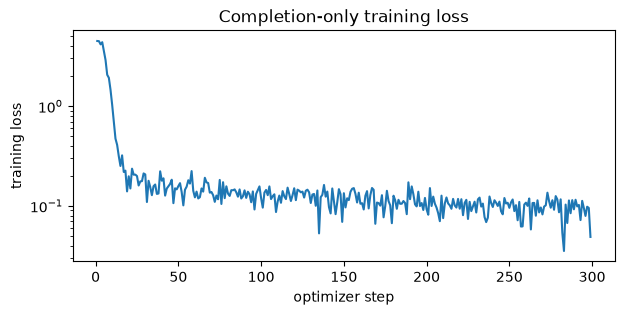

In [15]:
import matplotlib.pyplot as plt

losses = [
    row for row in support.load_jsonl(f"{RUN_DIR}/loss.jsonl") if "loss" in row
]
figure, axis = plt.subplots(figsize=(7, 3))
axis.plot([row["step"] for row in losses], [row["loss"] for row in losses])
axis.set_xlabel("optimizer step")
axis.set_ylabel("training loss")
axis.set_yscale("log")
axis.set_title("Completion-only training loss")
plt.show()

The exported model is checked against the base model's own GGUF: same
file type, architecture, chat template, tokenizer and tensor shapes. The
untuned weights sent through the same export (an *export-pipeline
control*) score exactly as the published baseline does, so whatever the
fine-tune changes is the training, not the export.

## 8. The comparison, per category

The fine-tuned model was evaluated by the unchanged harness, under the
unchanged configuration except for the model. `compare` refuses two
evaluations that differ in anything else.

In [16]:
from pmc_eval.compare import compare

CONFIGS = support.ROOT / "configs" / "evaluation"
comparison = compare(
    EVALUATION / "baseline",
    EVALUATION / "finetuned",
    CONFIGS / "baseline.json",
    CONFIGS / "finetuned.json",
    read_run,
)
rows = []
for set_name in ("test_gold", "heldout_synthetic"):
    for condition in ("no-grammar", "grammar"):
        block = comparison["sets"][set_name][condition]
        pair = block["paired_task_success"]
        tuned = block["overall"]["**TaskSuccess**"]["candidate"]
        key = f"{set_name}.{condition}"
        support.record(f"finetuned.{key}", tuned["k"])
        support.record(f"mcnemar.{key}", pair["mcnemar_exact_p"])
        rows.append(
            (
                set_name,
                condition,
                support.rate(0, pair["n"]),
                support.rate(tuned["k"], tuned["n"]),
                pair["only_candidate_succeeds"],
                pair["only_baseline_succeeds"],
                f"{pair['mcnemar_exact_p']:.2g}",
            )
        )
support.markdown_table(
    [
        "Set",
        "Condition",
        "Baseline",
        "Fine-tuned",
        "Only fine-tuned",
        "Only baseline",
        "McNemar p",
    ],
    rows,
)

| Set | Condition | Baseline | Fine-tuned | Only fine-tuned | Only baseline | McNemar p |
| --- | --- | --- | --- | --- | --- | --- |
| test_gold | no-grammar | 0/68 (0.0%, 0.0-5.3%) | 19/68 (27.9%, 18.7-39.6%) | 19 | 0 | 3.8e-06 |
| test_gold | grammar | 0/68 (0.0%, 0.0-5.3%) | 32/68 (47.1%, 35.7-58.8%) | 32 | 0 | 4.7e-10 |
| heldout_synthetic | no-grammar | 0/842 (0.0%, 0.0-0.5%) | 842/842 (100.0%, 99.5-100.0%) | 842 | 0 | 6.8e-254 |
| heldout_synthetic | grammar | 0/842 (0.0%, 0.0-0.5%) | 842/842 (100.0%, 99.5-100.0%) | 842 | 0 | 6.8e-254 |

**The fine-tune beats the baseline under both conditions on the primary
endpoint**, and every discordant pair favours it. On `heldout_synthetic`
it is right on every sample, but that set's intents come from the
training templates (section 5); the gold set, written in natural
language, is the honest measure. Per category, and the categories that
collapse, on `test_gold`:

In [17]:
gold_comparison = comparison["sets"]["test_gold"]
for breakout in ("verb_set", "term", "shape"):
    rows = []
    for group, grammar_rate in gold_comparison["grammar"]["breakouts"][
        breakout
    ].items():
        plain = gold_comparison["no-grammar"]["breakouts"][breakout][group]
        rows.append(
            (
                group,
                grammar_rate["candidate"]["n"],
                f"{plain['candidate']['k']}/{plain['candidate']['n']}",
                f"{grammar_rate['candidate']['k']}/{grammar_rate['candidate']['n']}",
            )
        )
    display(
        support.markdown_table([breakout, "n", "no-grammar", "grammar"], rows)
    )

collapsed = sorted(
    group
    for group, value in gold_comparison["grammar"]["breakouts"]["shape"].items()
    if value["candidate"]["k"] == 0
    and gold_comparison["no-grammar"]["breakouts"]["shape"][group]["candidate"][
        "k"
    ]
    == 0
)
support.record("collapsed.shapes", collapsed)
print("expression shapes with no success under either condition:", collapsed)

| verb_set | n | no-grammar | grammar |
| --- | --- | --- | --- |
| color | 13 | 1/13 | 4/13 |
| color+select | 10 | 2/10 | 3/10 |
| color+select+show | 7 | 1/7 | 4/7 |
| color+show | 1 | 0/1 | 0/1 |
| hide | 10 | 5/10 | 6/10 |
| hide+select | 5 | 3/5 | 3/5 |
| hide+show | 4 | 0/4 | 1/4 |
| orient+select | 6 | 3/6 | 6/6 |
| show | 12 | 4/12 | 5/12 |

| term | n | no-grammar | grammar |
| --- | --- | --- | --- |
| chain | 29 | 7/29 | 14/29 |
| hetatm | 12 | 7/12 | 8/12 |
| name | 13 | 4/13 | 4/13 |
| resi | 15 | 3/15 | 7/15 |
| resn | 19 | 0/19 | 3/19 |

| shape | n | no-grammar | grammar |
| --- | --- | --- | --- |
| and | 9 | 2/9 | 3/9 |
| and+not | 4 | 0/4 | 1/4 |
| and_or | 6 | 0/6 | 0/6 |
| or | 5 | 0/5 | 0/5 |
| single | 38 | 15/38 | 23/38 |
| single+not | 6 | 2/6 | 5/6 |

expression shapes with no success under either condition: ['and_or', 'or']


What still fails is **paraphrase**. Without the grammar the model often
keeps the user's own verb ("make the zinc ions magenta" becomes `make
magenta, ...`), which the language does not have. With the grammar
every plan parses, and most wrong plans have the right verbs but the
wrong selection: an everyday name turned into an invented atom name
("the alpha carbons" as `name ALPH`), or "chains A and B" read as `and`
where the user means either. Expressions joined by `or` collapse
completely, a direct consequence of that reading. The training intents
are templated; natural phrasing is where the next dataset has to grow.

## 9. Using the model: the copilot in PyMOL

This is what a user does. The server loads the fine-tuned model through
Lemonade, a local inference server, and serves the request graph over a
loopback connection. Inside PyMOL, the client registers the `copilot`
commands. The user types an intent, reads the preview, and applies it.

The server is started with the fine-tuned model's settings: the
model's name and file, a 16,384-token context (the structure card lists
every atom), the prompt the model was trained on, and the grammar.

In [18]:
CHECKPOINT = (
    "/models/train-e6c6c4dd8f6caaf9/export/"
    "Llama-3.2-1B-Instruct-pmc-train-e6c6c4dd8f6caaf9-Q4_K_M.gguf"
)
SERVER_FLAGS = [
    "--model-name",
    "Llama-3.2-1B-Instruct-pmc-train-e6c6c4dd8f6caaf9-Q4_K_M",
    "--checkpoint",
    CHECKPOINT,
    "--backend",
    "cuda",
    "--context-size",
    "16384",
    "--read-timeout-seconds",
    "600",
    "--prompt",
    "training",
    "--grammar",
    "--max-tokens",
    "256",
    "--generation-deadline-seconds",
    "600",
]
print("python -m pmc_server.main", " ".join(SERVER_FLAGS))

python -m pmc_server.main --model-name Llama-3.2-1B-Instruct-pmc-train-e6c6c4dd8f6caaf9-Q4_K_M --checkpoint /models/train-e6c6c4dd8f6caaf9/export/Llama-3.2-1B-Instruct-pmc-train-e6c6c4dd8f6caaf9-Q4_K_M.gguf --backend cuda --context-size 16384 --read-timeout-seconds 600 --prompt training --grammar --max-tokens 256 --generation-deadline-seconds 600


PyMOL starts headless in this kernel and loads a structure the model
never saw in training: the held-out `two_chains_hetatm`, two chains with
a zinc ion and a water. Then the client connects to the server.

In [19]:
import tempfile

from pmc_client.bootstrap import connect_from_handoff
from pmc_client.recovery import RecoveryStore
from pmc_core.snapshot import reconstruct

output_lines: list[str] = []
if RUN_DEMO:
    workdir = Path(tempfile.mkdtemp(prefix="pmc-notebook-"))
    handoff = workdir / "session.json"
    server = support.start_server(SERVER_FLAGS, handoff)
    cmd = support.launch_pymol()
    reconstruct(cmd, snapshot)
    driver = support.ConsoleDriver(cmd)
    client = connect_from_handoff(
        driver,
        output_lines.append,
        path=handoff,
        recovery_store=RecoveryStore(workdir),
    )
    print("\n".join(output_lines))
    output_lines.clear()
else:
    print("RUN_DEMO is off: set PMC_NOTEBOOK_DEMO=1 with the server running.")

cmd.sync() timed out (lock_attempt)


cmd.sync() timed out (lock_attempt)


cmd.sync() timed out (lock_attempt)


cmd.sync() timed out (lock_attempt)


cmd.sync() timed out (lock_attempt)
copilot: connected to the server on 127.0.0.1:37665.


The user asks, in their own words. (This intent is gold item `gold_056`,
which the fine-tuned model got right in the evaluation; the next cell
tries one it has never seen.)

In [20]:
INTENT = "select the zinc ions, make them silver and show them as dots"
if RUN_DEMO:
    before_color = []
    cmd.iterate("resn ZN", "before_color.append(color)", space=locals())
    seconds = driver.run(f"copilot {INTENT}")
    preview = "\n".join(output_lines)
    output_lines.clear()
    print(preview)
    print(f"\n(answered in {seconds:.1f} s)")

PyMOL>copilot select the zinc ions, make them silver and show them as dots


copilot plan p-160d1d8c-2785-4448-bc97-d8a4cf32619a (expires 2026-09-29T20:50:19.109Z, in 5 min)
  object:    pmc_structure (36 atoms, 1 state)
  commands:
    1 | select copilot_sel0244, name ZN   -> 2 atoms
    2 | color silver, copilot_sel0244
    3 | show dots, copilot_sel0244
  warnings:  none
  fidelity:  exact on the declared state scope
  checked:   the plan parses, policy allows it, and a fresh PyMOL sidecar reconstructed this session's declared state exactly, then ran the plan against it -- the counts above are from that run
  NOT checked: whether this is scientifically what you meant
  apply:     copilot_apply p-160d1d8c-2785-4448-bc97-d8a4cf32619a
  reject:    copilot_reject p-160d1d8c-2785-4448-bc97-d8a4cf32619a

(answered in 9.3 s)


The preview shows the plan, how many atoms each selection matched when
the plan was rehearsed in a separate PyMOL process, and what was
checked. Nothing in the session has changed yet. (The model selected the
zinc by atom name, `name ZN`, where the gold plan uses the residue name,
`resn ZN`; on this structure both match the same two atoms, which is why
the evaluation scored it right. Lines such as `cmd.sync() timed out`
are PyMOL's own messages when run inside a notebook kernel; the commands
still complete, as the outputs show.) The user approves it:

In [21]:
if RUN_DEMO:
    plan_id = (
        preview.splitlines()[0].removeprefix("copilot plan ").split(" ")[0]
    )
    driver.run(f"copilot_apply {plan_id}")
    print("\n".join(output_lines))
    output_lines.clear()
    after_color = []
    cmd.iterate("resn ZN", "after_color.append(color)", space=locals())
    print("zinc colour index before:", before_color, "after:", after_color)
    print("selection created:", cmd.get_names("selections"))

PyMOL>copilot_apply p-160d1d8c-2785-4448-bc97-d8a4cf32619a


cmd.sync() timed out (wait_queue)


cmd.sync() timed out (wait_queue)


cmd.sync() timed out (wait_queue)
copilot_apply: plan p-160d1d8c-2785-4448-bc97-d8a4cf32619a applied. Recovery point retained at /tmp/pmc-notebook-vgw0ubps/.pymol-copilot/recovery/plan-160d1d8c-2785-4448-bc97-d8a4cf32619a.pse.
zinc colour index before: [6, 6] after: [5322, 5322]
selection created: ['copilot_sel0244']


And the same flow on an intent the model has never been evaluated on:

In [22]:
if RUN_DEMO:
    driver.run("copilot colour chain B marine and show it as sticks")
    print("\n".join(output_lines))
    output_lines.clear()

PyMOL>copilot colour chain B marine and show it as sticks


copilot plan p-dab25404-8e0e-4f8e-965e-d40cda421350 (expires 2026-09-29T20:50:30.201Z, in 5 min)
  object:    pmc_structure (36 atoms, 1 state)
  commands:
    1 | color marine, chain B
    2 | show sticks, chain B
  warnings:  none
  fidelity:  exact on the declared state scope
  checked:   the plan parses, policy allows it, and a fresh PyMOL sidecar reconstructed this session's declared state exactly, then ran the plan against it -- the counts above are from that run
  NOT checked: whether this is scientifically what you meant
  apply:     copilot_apply p-dab25404-8e0e-4f8e-965e-d40cda421350
  reject:    copilot_reject p-dab25404-8e0e-4f8e-965e-d40cda421350


A plan that is not what the user wanted is simply not applied: typing
`copilot_reject` discards it, and nothing changes. An applied plan can
be undone as a whole, because the session was saved before it ran:

In [23]:
if RUN_DEMO:
    driver.run(f"copilot_rollback {plan_id}")
    print("\n".join(output_lines))
    output_lines.clear()
    restored = []
    cmd.iterate("resn ZN", "restored.append(color)", space=locals())
    print("zinc colour index after rollback:", restored)
    support.stop_server(server)

PyMOL>copilot_rollback p-160d1d8c-2785-4448-bc97-d8a4cf32619a
copilot_rollback: replacing the entire session with the pre-apply recovery point; later changes will be discarded.
copilot_rollback: plan p-160d1d8c-2785-4448-bc97-d8a4cf32619a rolled back and its recovery point was removed.
zinc colour index after rollback: [6, 6]


## 10. Limits, versions, licensing and retention

### What V1 does not do

Cut from V1 before building, as the specification permits:

- fetching structures from the PDB inside the tool;
- the `label`, `set` and measurement command families;
- quantization studies (the model is used at Q4_K_M only);
- grammar terminals conditioned on the structure (the grammar admits
  any chain letter, not only the chains present);
- multi-seed variance and ablations: **one training run, one seed**.

Declared unsupported, and marked rather than dropped:

- the `polymer` term is never graded (PyMOL's own classification is not
  recorded);
- `orient` is graded on selection counts only (camera view);
- `nonbonded`, `slice`, `ellipsoids` and `volume` representations are not
  checked; every `slice` sample was excluded after the label audit;
- measurement objects and PyMOL's polymer flag are outside the snapshot;
- the structures are synthetic and backbone-only (ALA, SER, GLY, VAL,
  LEU, ZN, HOH); `show cartoon` sets a flag but draws nothing on them;
- the split is by structure, not by sequence cluster, and the training
  intents are templated;
- the integrated-GPU route (Lemonade's Vulkan backend) is **unproven**:
  CPU and a discrete NVIDIA GPU were measured.

The specification's optional evidence, and what became of it:

| Item | Status |
| --- | --- |
| untuned base-model baseline | done, pre-registered |
| retrieval-plus-grammar and teacher baselines | not attempted |
| size and quantization Pareto comparison | not attempted |
| multiple seeds with uncertainty | not attempted (one seed) |
| card, grammar and model-size ablations | not attempted; the grammar condition is reported alongside |
| full post-quantization re-evaluation | not attempted (only Q4_K_M evaluated) |
| integrated-agent TaskSuccess | not measured; section 9 shows the flow on two intents only |
| rejection sampling or reinforcement learning | not attempted |

### Versions

In [24]:
engine = support.load_json("configs/evaluation/finetuned.json")
provenance_engine = engine["engine_provenance"]
support.record("versions.lemonade", provenance_engine["lemonade_version"])
support.record("versions.llama_cpp", provenance_engine["llama_cpp_build"])
support.record("versions.pymol_wheel", manifest["provenance"]["pymol_wheel"])
host = support.host_description()
rows = [
    (
        "operating system (training, evaluation, notebook)",
        f"{host['os']} under WSL2, Windows 10.0.26200.9457",
    ),
    ("operating system (dataset split)", "macOS 15.6.1, MacBook Pro M2"),
    ("architecture", host["architecture"]),
    ("kernel", host["kernel"]),
    ("host", provenance_engine["host"]),
    (
        "Open-Source PyMOL",
        f"{manifest['provenance']['pymol_wheel']} (reports {manifest['provenance']['versions']['pymol_version']})",
    ),
    ("Python (runtime, Bazel)", "3.13.13"),
    ("Python (training and this notebook)", host["python"]),
    (
        "Lemonade",
        f"{provenance_engine['lemonade_version']}, image {provenance_engine['image'].split('@')[-1][:19]}...",
    ),
    (
        "llama.cpp",
        f"{provenance_engine['llama_cpp_build']} (GPU engine and export), b10723 (CPU backend)",
    ),
    ("base model", "Llama-3.2-1B-Instruct, Q4_K_M, GGUF 3f5a2242..."),
    (
        "fine-tuned model",
        f"{engine['engine']['model_name']}, GGUF {provenance_engine['gguf_sha256'][:16]}...",
    ),
    ("contract versions", manifest["provenance"]["versions"]),
]
rows += support.package_versions(
    ["torch", "transformers", "peft", "unsloth", "unsloth_zoo", "langgraph"]
)
support.markdown_table(["Component", "Version"], rows)

| Component | Version |
| --- | --- |
| operating system (training, evaluation, notebook) | Ubuntu 24.04.4 LTS under WSL2, Windows 10.0.26200.9457 |
| operating system (dataset split) | macOS 15.6.1, MacBook Pro M2 |
| architecture | x86_64 |
| kernel | Linux 5.15.167.4-microsoft-standard-WSL2 |
| host | Linux 5.15.167.4-microsoft-standard-WSL2 x86_64; NVIDIA GeForce RTX 4060, 610.74; WSL2 |
| Open-Source PyMOL | pymol-open-source-whl==3.2.0.2 (reports 3.2.0a) |
| Python (runtime, Bazel) | 3.13.13 |
| Python (training and this notebook) | 3.12.13 |
| Lemonade | 11.9.0, image sha256:3873d3ec672e... |
| llama.cpp | b10707 (GPU engine and export), b10723 (CPU backend) |
| base model | Llama-3.2-1B-Instruct, Q4_K_M, GGUF 3f5a2242... |
| fine-tuned model | Llama-3.2-1B-Instruct-pmc-train-e6c6c4dd8f6caaf9-Q4_K_M, GGUF 6c5c76a01291b5fe... |
| contract versions | {'card_version': 1, 'executor_version': 1, 'grammar_version': 1, 'policy_version': 1, 'prompt_version': 1, 'protocol_version': '1', 'pymol_version': '3.2.0a', 'snapshot_version': 1} |
| torch | 2.12.1 |
| transformers | 5.5.0 |
| peft | 0.21.0 |
| unsloth | 2026.9.5 |
| unsloth_zoo | 2026.9.4 |
| langgraph | 1.2.11 |

### Licensing

Nothing here is published; the record is kept so that it could be.

In [25]:
licence = manifest["license"]
rows = [
    ("this repository's code", licence["code"]),
    ("the dataset's structures", licence["structures"]),
    ("the gold intents", licence["gold_intents"]),
    ("teacher outputs", licence["teacher_outputs"]),
    (
        "Open-Source PyMOL",
        "Open-Source PyMOL Copyright Notice (BSD-like), from the wheel's metadata",
    ),
    (
        "Llama 3.2 (base and fine-tuned model)",
        "Llama 3.2 Community License and Acceptable Use Policy; models named with a leading 'Llama'; 'Built with Llama'",
    ),
    (
        "Lemonade",
        "Apache-2.0 (its repository's LICENSE at tag v11.9.0; the image carries none)",
    ),
    ("llama.cpp", "MIT (the pinned checkout's LICENSE)"),
]
rows += [
    (name, support.package_licence(name))
    for name in (
        "unsloth",
        "unsloth_zoo",
        "torch",
        "transformers",
        "peft",
        "langgraph",
    )
]
support.markdown_table(["Component", "Licence"], rows)

| Component | Licence |
| --- | --- |
| this repository's code | BSD 3-Clause License; Copyright (c) 2026, Martin Urban (LICENSE) |
| the dataset's structures | authored synthetically in this repository by pmc_data.structures; no PDB or wwPDB-derived data |
| the gold intents | written for this repository: drafted by claude-opus-5-5 and reviewed and edited by Martin |
| teacher outputs | none; training intents are templated by pmc_data.taxonomy |
| Open-Source PyMOL | Open-Source PyMOL Copyright Notice (BSD-like), from the wheel's metadata |
| Llama 3.2 (base and fine-tuned model) | Llama 3.2 Community License and Acceptable Use Policy; models named with a leading 'Llama'; 'Built with Llama' |
| Lemonade | Apache-2.0 (its repository's LICENSE at tag v11.9.0; the image carries none) |
| llama.cpp | MIT (the pinned checkout's LICENSE) |
| unsloth | Apache-2.0 |
| unsloth_zoo | LGPL-3.0-or-later |
| torch | BSD-3-Clause |
| transformers | Apache 2.0 License |
| peft | Apache |
| langgraph | MIT |

Two notes. `unsloth_zoo`, used only during training, is LGPL-3.0; it is
not part of the model or the runtime. The repository's README badge
points to GPL-3.0 while its `LICENSE` file is BSD 3-Clause; the file is
authoritative and the badge is a known inconsistency.

### Retention and deletion

- Generated datasets live under `data/`, which is not committed. A
  split is identified by the hash of its files, recorded in the
  committed manifest, and a directory is never overwritten; a new run
  writes a new one.
- Evaluation runs and training runs live under `results/`, not
  committed. Their records (configuration, seeds, hashes, per-sample
  outcomes) are copied into `docs/` and committed; the model weights are
  not, and are never uploaded.
- PyMOL recovery points are private files under `~/.pymol-copilot/`,
  consumed by a rollback and otherwise kept until the user deletes them.
- No user data is collected; nothing leaves the machine.

In [26]:
support.print_record()

pmc-notebook-record
{
 "audit.v1.wrong": 1,
 "audit.v2.judged": 50,
 "audit.v2.wrong": 0,
 "baseline.heldout_synthetic.grammar": 0,
 "baseline.heldout_synthetic.no-grammar": 0,
 "baseline.test_gold.grammar": 0,
 "baseline.test_gold.no-grammar": 0,
 "collapsed.shapes": [
  "and_or",
  "or"
 ],
 "conformance.attempted": 4000,
 "conformance.crashes_kept_on_rerun": 7,
 "conformance.kept": 3381,
 "conformance.rejected": 7,
 "conformance.rejected_by_reason": {
  "child_crash": 7
 },
 "conformance.unsupported": 612,
 "finetuned.heldout_synthetic.grammar": 842,
 "finetuned.heldout_synthetic.no-grammar": 842,
 "finetuned.test_gold.grammar": 32,
 "finetuned.test_gold.no-grammar": 19,
 "mcnemar.heldout_synthetic.grammar": 6.819831532519088e-254,
 "mcnemar.heldout_synthetic.no-grammar": 6.819831532519088e-254,
 "mcnemar.test_gold.grammar": 4.656612873077393e-10,
 "mcnemar.test_gold.no-grammar": 3.814697265625e-06,
 "split.decontam_dropped": 68,
 "split.excluded": 89,
 "split.heldout_synthetic": 84